# AFML 第 2 章：Financial Data Structures —— 读书笔记

> **来源**：Marcos López de Prado, *Advances in Financial Machine Learning*, Chapter 2 (pp. 23–40)
> **目标**：把整章的核心思想整理清楚，并把所有重要算法做成可直接运行的 Python 模块。

## 章节结构

1. **§2.2 四类金融数据**：fundamental / market / analytics / alternative
2. **§2.3 Bars**：把非均匀到达的数据变成结构化样本
   - §2.3.1 Standard bars：time / tick / volume / dollar
   - §2.3.2 Information-driven bars：TIB / VIB / DIB / TRB / VRB / DRB
3. **§2.4 多产品序列**：ETF trick / PCA weights / 期货 roll
4. **§2.5 Sampling features**：downsampling + event-based (CUSUM filter)

这份 notebook 把第 2、3、4 部分的算法都实现出来，并用合成数据演示每一种 bar 的效果。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Sequence

np.random.seed(42)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True


---

## 1. 合成一段 tick 数据用于全章演示

后面所有 bar 构造都需要 tick-level 数据。真实环境下应该用 FIX feed 或交易所历史数据；这里用一个**带漂移和波动率聚集的几何布朗运动 + 非均匀到达时间**来模拟。

每条 tick 包含三个字段：`timestamp`, `price`, `volume`。


In [2]:
def simulate_ticks(n_ticks: int = 50_000,
                   start_price: float = 100.0,
                   drift: float = 0.05,
                   vol: float = 0.20,
                   seed: int = 42) -> pd.DataFrame:
    """生成合成 tick 数据。

    - 到达间隔用指数分布（Poisson 过程），并在日内 U 形活跃度上做调整。
    - 价格用对数随机游走，每个 tick 一个微小步长。
    - 成交量来自对数正态分布。
    """
    rng = np.random.default_rng(seed)

    # 到达时间：指数间隔 + U 形日内活跃度调节
    inter_arrivals = rng.exponential(scale=1.0, size=n_ticks)
    t = np.cumsum(inter_arrivals)
    t = t / t[-1]  # 归一到 [0, 1]
    # U 形：开盘和收盘 tick 更密
    u_shape_factor = 0.5 + 2.0 * (t - 0.5) ** 2
    inter_adj = inter_arrivals / u_shape_factor
    t_adj = np.cumsum(inter_adj)
    timestamps = pd.Timestamp('2024-01-01 09:30:00') + pd.to_timedelta(
        t_adj / t_adj[-1] * 6.5 * 3600, unit='s'
    )  # 压缩到 6.5 小时交易日

    # 价格：每个 tick 一个小的对数收益
    dt = np.diff(np.concatenate([[0.0], t_adj])) / t_adj[-1]
    log_ret = (drift - 0.5 * vol ** 2) * dt + vol * np.sqrt(dt) * rng.standard_normal(n_ticks)
    price = start_price * np.exp(np.cumsum(log_ret))

    # 成交量：对数正态
    volume = rng.lognormal(mean=2.0, sigma=0.8, size=n_ticks).round().astype(int)
    volume = np.clip(volume, 1, None)

    return pd.DataFrame({
        'timestamp': timestamps,
        'price': price,
        'volume': volume,
    })


ticks = simulate_ticks()
print(f"生成 {len(ticks):,} 条 tick")
print(f"时间跨度：{ticks['timestamp'].iloc[0]} → {ticks['timestamp'].iloc[-1]}")
print(f"价格区间：[{ticks['price'].min():.2f}, {ticks['price'].max():.2f}]")
print(f"总成交量：{ticks['volume'].sum():,}")
print(f"总成交额：${(ticks['price'] * ticks['volume']).sum():,.0f}")
ticks.head()


生成 50,000 条 tick
时间跨度：2024-01-01 09:30:00.716086887 → 2024-01-01 16:00:00
价格区间：[85.40, 108.58]
总成交量：510,520
总成交额：$50,588,692


,timestamp,price,volume
0,2024-01-01 09:30:00.716086887,100.0051,12
1,2024-01-01 09:30:01.411979519,100.0607,5
2,2024-01-01 09:30:02.122408081,100.0611,10
3,2024-01-01 09:30:02.205760701,100.0969,18
4,2024-01-01 09:30:02.231511079,100.0886,11


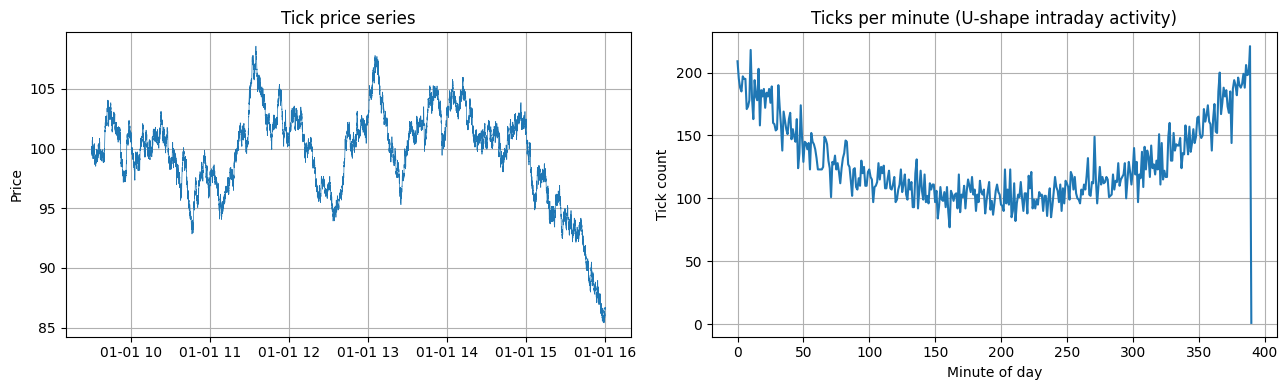

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ticks['timestamp'], ticks['price'], lw=0.5)
axes[0].set_title('Tick price series')
axes[0].set_ylabel('Price')

# 每分钟 tick 数 → 验证 U 形
tick_per_min = ticks.set_index('timestamp').resample('1min').size()
axes[1].plot(tick_per_min.values)
axes[1].set_title('Ticks per minute (U-shape intraday activity)')
axes[1].set_xlabel('Minute of day')
axes[1].set_ylabel('Tick count')
plt.tight_layout(); plt.show()


---

## 2. §2.2 四类金融数据

| 类型 | 内容 | 频率 | 关键陷阱 |
|------|------|------|----------|
| **Fundamental** | 资产、负债、销售、成本、宏观变量 | 季度 | ① 报告日 ≠ 公开日（lag ~1.5 个月）；② backfilling / reinstated values 制造 look-ahead bias |
| **Market** | 价格、成交量、报价、撤单、aggressor side | tick 级 | 异常 tick（开收盘集合竞价聚合）；订单碎片化 |
| **Analytics** | 分析师评级、信用评级、新闻情绪 | 不定 | 二手加工，方法论可能不透明，存在偏差 |
| **Alternative** | 卫星图、社交媒体、地理位置、CCTV | 不定 | 贵、隐私问题、难处理（但正因如此才有 alpha） |

### 2.1 Fundamental data 的两个核心坑

**陷阱 1：报告日 ≠ 公开日**
Bloomberg 把财报数值 index 到**报告期末**（如 Q1 末 = 3/31），但实际公开时点往往晚 1.5 个月。如果按报告期末做回测就引入了 look-ahead bias。

**陷阱 2：Backfilling & reinstated values**
- *Backfilling*：缺失值被事后填上（即便当时并未知）。
- *Reinstated value*：财报数据被多次修订，数据商通常用最终修订值覆盖初版。
- 解决方案：**point-in-time (PIT) 数据库**，或保留 multiple release dates（典型例：GDP 通常存 original + 2 revisions）。

### 2.2 Market data
FIX 消息可重建订单簿，一天 10+ TB。**难处理 = alpha 来源**。

### 2.3 Alternative data
de Prado 的金句：
> "Data that is hard to store, manipulate, and operate is the one most promising. You will recognize that a dataset may be useful if it annoys your IT/infrastructure team."

下面一个小工具用来模拟"PIT 视角"和"修订视角"的差异，帮助直观感受陷阱 2。


In [4]:
def demonstrate_revision_bias():
    """模拟一个季度 GDP 数据的三次发布：原始 + 两次修订。

    展示用最终修订值替代原始值会带来多大的 look-ahead bias。
    """
    quarters = pd.date_range('2020-03-31', periods=8, freq='QE')
    # 假设真实 = 最终修订值，原始发布是真实值加噪声
    true_values = np.array([2.1, -8.5, 7.5, 4.2, 6.4, 6.7, 2.3, 3.2])
    rng = np.random.default_rng(0)
    original = true_values + rng.normal(0, 0.8, size=len(true_values))
    revision1 = true_values + rng.normal(0, 0.3, size=len(true_values))
    final = true_values

    release_dates = quarters + pd.Timedelta(days=30)   # 原始发布 +1 个月
    rev1_dates = quarters + pd.Timedelta(days=60)      # 第一次修订 +2 个月
    final_dates = quarters + pd.Timedelta(days=90)     # 终版 +3 个月

    df = pd.DataFrame({
        'quarter_end': quarters,
        'original_release_date': release_dates,
        'original_value': original.round(2),
        'revision1_value': revision1.round(2),
        'final_value': final.round(2),
        'naive_lookahead_error': (final - original).round(2),
    })
    return df


revisions = demonstrate_revision_bias()
revisions


,quarter_end,original_release_date,original_value,revision1_value,final_value,naive_lookahead_error
0,2020-03-31,2020-04-30,2.2000,1.8900,2.1000,-0.1000
1,2020-06-30,2020-07-30,-8.6100,-8.8800,-8.5000,0.1100
2,2020-09-30,2020-10-30,8.0100,7.3100,7.5000,-0.5100
3,2020-12-31,2021-01-30,4.2800,4.2100,4.2000,-0.0800
4,2021-03-31,2021-04-30,5.9700,5.7000,6.4000,0.4300
5,2021-06-30,2021-07-30,6.9900,6.6300,6.7000,-0.2900
6,2021-09-30,2021-10-30,3.3400,1.9300,2.3000,-1.0400
7,2021-12-31,2022-01-30,3.9600,2.9800,3.2000,-0.7600


---

## 3. §2.3.1 Standard Bars

把非均匀到达的 tick 流转成均匀样本。**问题：用什么作为"时钟"？**

### 3.1 Time Bars —— de Prado 明确反对

- 做法：固定时间间隔（每分钟 / 每小时）采样 OHLCV + VWAP。
- 缺点：
  1. **过采样冷清时段、欠采样热闹时段**（市场不按物理时间处理信息）
  2. 收益序列严重 **serial correlation、heteroskedasticity、non-normality**——GARCH 的出现部分就是为了打这个补丁

### 3.2 Tick Bars —— 每 N 笔交易一个样本

Mandelbrot & Taylor (1967) 早就发现：按 tick 数采样的收益更接近高斯分布。
直觉：固定时间内的 tick 数本身是随机的，固定 tick 数能"对齐信息到达节奏"。

**坑**：开盘 / 收盘集合竞价产生一笔异常大成交，要做 outlier 检测。

### 3.3 Volume Bars —— 每 N 单位成交一个样本

解决 tick bar 的**订单碎片化**问题：
- 一笔 10 手买单打到一个 10 手卖单 → 1 个 tick
- 一笔 10 手买单打到 10 个 1 手卖单 → 10 个 tick

→ Clark (1973): volume bars 的统计性质更接近 IID 高斯。

### 3.4 Dollar Bars —— 每 N 美元成交额一个样本

de Prado 认为这是 standard bars 中**最好的**：
1. 对**价格漂移**鲁棒：股票一年涨 100%，年末用 1000 美元能买的股数是年初的一半，单纯按"股数"采样会被价格漂移污染。
2. 对**corporate actions**（增发、回购、拆股）鲁棒。
3. Figure 2.1（E-mini S&P 500, 2006–2018）：dollar bars 每日数量最稳定。

下面统一实现一个 `bar_builder` 模块。


In [5]:
@dataclass
class Bar:
    """通用 bar 数据结构。"""
    timestamp: pd.Timestamp  # bar 结束时刻
    open: float
    high: float
    low: float
    close: float
    vwap: float
    volume: int
    n_ticks: int
    dollar_value: float


def _finalize_bar(group: pd.DataFrame) -> dict:
    """把一组 ticks 聚合为一个 bar。"""
    p = group['price'].values
    v = group['volume'].values
    dv = p * v
    total_v = v.sum()
    return {
        'timestamp': group['timestamp'].iloc[-1],
        'open': p[0],
        'high': p.max(),
        'low': p.min(),
        'close': p[-1],
        'vwap': dv.sum() / total_v if total_v > 0 else p.mean(),
        'volume': int(total_v),
        'n_ticks': len(group),
        'dollar_value': dv.sum(),
    }


def time_bars(ticks: pd.DataFrame, freq: str = '5min') -> pd.DataFrame:
    """按固定时间窗口聚合 ticks。"""
    t = ticks.copy()
    t['bin'] = t['timestamp'].dt.floor(freq)
    bars = [_finalize_bar(g) for _, g in t.groupby('bin') if len(g) > 0]
    return pd.DataFrame(bars)


def _threshold_bars(ticks: pd.DataFrame, threshold: float, metric: str) -> pd.DataFrame:
    """通用门限式 bar 构造器：累计量 metric 达到 threshold 就切一个 bar。

    metric in {'tick', 'volume', 'dollar'}
    """
    bars = []
    start = 0
    cum = 0.0
    p = ticks['price'].values
    v = ticks['volume'].values

    for i in range(len(ticks)):
        if metric == 'tick':
            cum += 1
        elif metric == 'volume':
            cum += v[i]
        elif metric == 'dollar':
            cum += p[i] * v[i]
        else:
            raise ValueError(metric)

        if cum >= threshold:
            bars.append(_finalize_bar(ticks.iloc[start:i + 1]))
            start = i + 1
            cum = 0.0

    # 残余 ticks 形成最后一个不完整 bar（可选丢弃）
    if start < len(ticks):
        bars.append(_finalize_bar(ticks.iloc[start:]))
    return pd.DataFrame(bars)


def tick_bars(ticks, n_ticks_per_bar=500):
    return _threshold_bars(ticks, n_ticks_per_bar, 'tick')


def volume_bars(ticks, volume_per_bar=5_000):
    return _threshold_bars(ticks, volume_per_bar, 'volume')


def dollar_bars(ticks, dollar_per_bar=500_000):
    return _threshold_bars(ticks, dollar_per_bar, 'dollar')


# 构造四种 bar，调整阈值使每种产出 bar 数量大致相当（便于对比）
tb_time = time_bars(ticks, freq='5min')
tb_tick = tick_bars(ticks, n_ticks_per_bar=500)
tb_vol = volume_bars(ticks, volume_per_bar=int(ticks['volume'].sum() / 100))
tb_dol = dollar_bars(ticks, dollar_per_bar=int((ticks['price'] * ticks['volume']).sum() / 100))

print(f"{'Bar type':<15} {'# bars':>8} {'avg ticks/bar':>15} {'avg dollar/bar':>18}")
for name, b in [('time', tb_time), ('tick', tb_tick), ('volume', tb_vol), ('dollar', tb_dol)]:
    print(f"{name:<15} {len(b):>8d} {b['n_ticks'].mean():>15.1f} {b['dollar_value'].mean():>18,.0f}")


Bar type          # bars   avg ticks/bar     avg dollar/bar
time                  79           632.9            640,363
tick                 100           500.0            505,887
volume               100           500.0            505,887
dollar               100           500.0            505,887


**复现 Figure 2.1 风格的对比**：每种 bar 在等长时间窗口内的 bar 数量稳定性。理论上 dollar bar 应该最稳定。


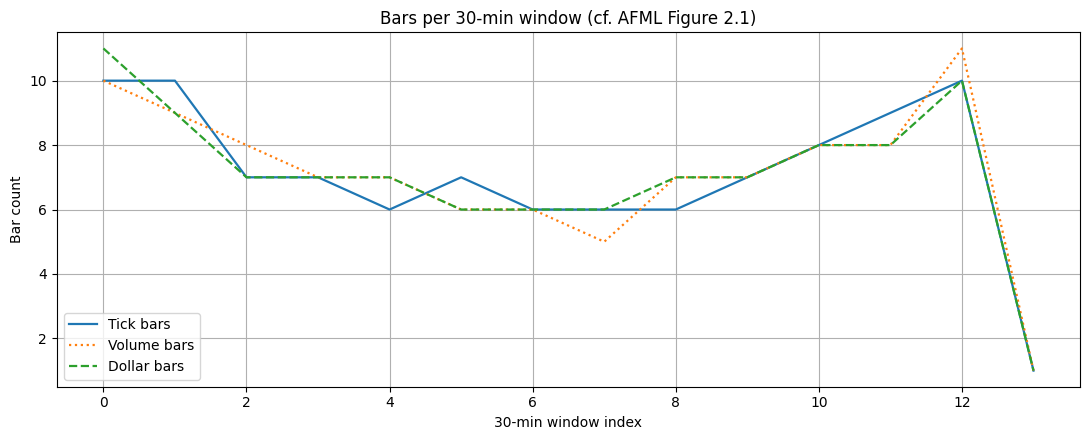


收益序列相关性（绝对值越小越接近 IID）:
      time bars: lag-1 autocorr = -0.0742, n_obs = 78
      tick bars: lag-1 autocorr = -0.1671, n_obs = 99
    volume bars: lag-1 autocorr = -0.1577, n_obs = 99
    dollar bars: lag-1 autocorr = -0.1476, n_obs = 99


In [6]:
def bars_per_window(bars: pd.DataFrame, freq: str = '30min') -> pd.Series:
    return bars.set_index('timestamp').resample(freq).size()


fig, ax = plt.subplots(figsize=(11, 4.5))
for label, b, style in [
    ('Tick bars', tb_tick, '-'),
    ('Volume bars', tb_vol, ':'),
    ('Dollar bars', tb_dol, '--'),
]:
    s = bars_per_window(b, '30min')
    ax.plot(s.values, label=label, linestyle=style, lw=1.6)
ax.set_title('Bars per 30-min window (cf. AFML Figure 2.1)')
ax.set_xlabel('30-min window index')
ax.set_ylabel('Bar count')
ax.legend()
plt.tight_layout(); plt.show()

# 习题 2.1(c)：收益序列相关性对比
print("\n收益序列相关性（绝对值越小越接近 IID）:")
for label, b in [('time', tb_time), ('tick', tb_tick), ('volume', tb_vol), ('dollar', tb_dol)]:
    r = b['close'].pct_change().dropna()
    print(f"  {label:>8} bars: lag-1 autocorr = {r.autocorr(1):+.4f}, n_obs = {len(r)}")


---

## 4. §2.3.2 Information-Driven Bars

**核心动机**：standard bars 用交易量代理"信息到达"，但更好的代理是**订单流的不平衡**。informed trader 入场时会出现单边成交，应该在不平衡积累到一定程度时**立刻**采样，而不是等够 N 个 tick / N 单位成交。

### 4.1 Tick Rule

所有 information-driven bars 都基于这个分类器：

$$b_t = \begin{cases} b_{t-1} & \text{if } \Delta p_t = 0 \\ \mathrm{sign}(\Delta p_t) & \text{otherwise} \end{cases}$$

$b_t \in \{-1, +1\}$ 表示该 tick 是 buy(+1) 还是 sell(-1)，由价格变动方向推断。

### 4.2 六种 bar 一览

| 名称 | 缩写 | 累计量 $\theta_T$ | 期望 $\mathbb{E}_0[\theta_T]$ |
|------|------|-------------------|-------------------------------|
| Tick Imbalance | TIB | $\sum b_t$ | $\mathbb{E}_0[T] \cdot \lvert 2P[b_t{=}1] - 1\rvert$ |
| Volume Imbalance | VIB | $\sum b_t v_t$（v=股数） | $\mathbb{E}_0[T] \cdot \lvert 2v^+ - \mathbb{E}_0[v_t]\rvert$ |
| Dollar Imbalance | DIB | $\sum b_t v_t$（v=美元） | 同上，v 换成美元 |
| Tick Runs | TRB | $\max\{\sum_{b_t{=}1} b_t,\ -\sum_{b_t{=}-1} b_t\}$ | $\mathbb{E}_0[T] \cdot \max\{P[b_t{=}1], 1{-}P[b_t{=}1]\}$ |
| Volume Runs | VRB | 各方向 $\sum b_t v_t$ 的最大 | 类似 |
| Dollar Runs | DRB | 同上，v 换成美元 | 类似 |

**触发条件统一为**：$T^* = \arg\min_T \{\lvert\theta_T\rvert \geq \mathbb{E}_0[\theta_T]\}$

所有期望都用**前 N 个 bar 的 EWMA** 估计。

### 4.3 Imbalance vs Runs 的区别

- **Imbalance bars**：累计带符号量，正负**互相抵消**。
- **Runs bars**：分别累计两侧的总量，取最大值，**不抵消**。
  - 原因：大单常被切成 iceberg / child orders，单看"最长连续段"会漏；累计每一侧能更敏感地捕捉到这种切单行为。


In [7]:
def apply_tick_rule(prices: np.ndarray, b0: int = 1) -> np.ndarray:
    """Tick rule: b_t = sign(Delta p_t); if Delta p_t = 0 inherit b_{t-1}.

    First tick uses boundary condition b0.
    """
    dp = np.diff(prices, prepend=prices[0])
    b = np.zeros(len(prices), dtype=int)
    last = b0
    for i, d in enumerate(dp):
        if d > 0:
            last = 1
        elif d < 0:
            last = -1
        # d == 0 时 last 保持
        b[i] = last
    return b


# 把 tick rule 加到 ticks 上
ticks['b'] = apply_tick_rule(ticks['price'].values)
print("Tick rule 分布：")
print(ticks['b'].value_counts())
print(f"\nP[b_t = +1] = {(ticks['b'] == 1).mean():.4f}")


Tick rule 分布：
b
-1    25248
 1    24752
Name: count, dtype: int64

P[b_t = +1] = 0.4950


In [8]:
def _ewma_update(prev: float, new: float, alpha: float) -> float:
    """标量 EWMA：new_ewma = alpha * new + (1 - alpha) * prev"""
    return alpha * new + (1 - alpha) * prev


def imbalance_bars(ticks: pd.DataFrame,
                   mode: str = 'dollar',
                   ewma_window: int = 20,
                   init_expected_T: int = 1000,
                   init_expected_imbalance: float = 0.1) -> pd.DataFrame:
    """Imbalance bars 通用实现，支持 mode in {'tick', 'volume', 'dollar'}.

    触发条件：|cum_signed| >= E[T] * |2 v+ - E[v]|

    参数:
      ewma_window: EWMA 平滑窗口，alpha = 2 / (window + 1)
      init_expected_T: 第一个 bar 之前的 E[T] 初值
      init_expected_imbalance: |2 v+ - E[v]| 的初值
    """
    alpha = 2 / (ewma_window + 1)

    p = ticks['price'].values
    v = ticks['volume'].values
    b = ticks['b'].values

    if mode == 'tick':
        signed = b.astype(float)
    elif mode == 'volume':
        signed = b * v
    elif mode == 'dollar':
        signed = b * v * p
    else:
        raise ValueError(mode)

    bars = []
    start = 0
    cum = 0.0
    exp_T = float(init_expected_T)
    exp_imb = float(init_expected_imbalance)

    for i in range(len(ticks)):
        cum += signed[i]
        n = i - start + 1
        threshold = exp_T * abs(exp_imb)

        if abs(cum) >= threshold and n >= 5:  # 至少 5 个 tick，避免一开就切
            chunk = ticks.iloc[start:i + 1]
            bars.append(_finalize_bar(chunk))

            # EWMA 更新
            realized_imb = signed[start:i + 1].mean()
            exp_T = _ewma_update(exp_T, n, alpha)
            exp_imb = _ewma_update(exp_imb, realized_imb, alpha)

            start = i + 1
            cum = 0.0

    return pd.DataFrame(bars)


# Dollar Imbalance Bars (DIB)
dib = imbalance_bars(ticks, mode='dollar', ewma_window=20,
                     init_expected_T=500, init_expected_imbalance=50.0)
print(f"DIB: {len(dib)} 个 bar，平均每个 bar 含 {dib['n_ticks'].mean():.0f} 个 tick")
dib.head()


DIB: 72 个 bar，平均每个 bar 含 640 个 tick


,timestamp,open,high,low,close,vwap,volume,n_ticks,dollar_value
0,2024-01-01 09:31:29.438120130,100.0051,100.9485,99.1581,99.5451,99.9647,3255,319,325385.0143
1,2024-01-01 09:32:38.473514212,99.5251,100.4173,98.8586,98.8586,99.7549,2182,206,217665.2236
2,2024-01-01 09:33:29.622023245,98.8643,99.4847,98.5321,99.0182,98.9540,1775,155,175643.3110
3,2024-01-01 09:33:50.592604471,98.9922,99.7721,98.7878,99.7721,99.0571,633,73,62703.1573
4,2024-01-01 09:34:47.325745244,99.7742,99.9594,98.8998,99.6252,99.4631,1991,178,198031.1077


In [9]:
def runs_bars(ticks: pd.DataFrame,
              mode: str = 'dollar',
              ewma_window: int = 20,
              init_expected_T: int = 1000,
              init_expected_buy_value: float = 100.0,
              init_expected_sell_value: float = 100.0,
              init_p_buy: float = 0.5) -> pd.DataFrame:
    """Runs bars 通用实现，支持 mode in {'tick', 'volume', 'dollar'}.

    触发条件：
        theta_T = max( sum_{b=+1} v,  -sum_{b=-1} v )
        E[theta_T] = E[T] * max( P[b=+1]*E[v|b=+1],  (1-P[b=+1])*E[v|b=-1] )

    注意 runs 不是"最长连续段"，而是"每一侧的总累计"。
    """
    alpha = 2 / (ewma_window + 1)
    p = ticks['price'].values
    v = ticks['volume'].values
    b = ticks['b'].values

    if mode == 'tick':
        weight = np.ones(len(ticks))
    elif mode == 'volume':
        weight = v.astype(float)
    elif mode == 'dollar':
        weight = v * p
    else:
        raise ValueError(mode)

    bars = []
    start = 0
    cum_buy = 0.0
    cum_sell = 0.0
    exp_T = float(init_expected_T)
    exp_v_buy = float(init_expected_buy_value)
    exp_v_sell = float(init_expected_sell_value)
    p_buy = float(init_p_buy)

    for i in range(len(ticks)):
        if b[i] == 1:
            cum_buy += weight[i]
        else:
            cum_sell += weight[i]

        n = i - start + 1
        theta = max(cum_buy, cum_sell)
        expected = exp_T * max(p_buy * exp_v_buy, (1 - p_buy) * exp_v_sell)

        if theta >= expected and n >= 5:
            chunk = ticks.iloc[start:i + 1]
            bars.append(_finalize_bar(chunk))

            # EWMA 更新
            b_chunk = b[start:i + 1]
            w_chunk = weight[start:i + 1]
            realized_p_buy = (b_chunk == 1).mean()
            realized_v_buy = w_chunk[b_chunk == 1].mean() if (b_chunk == 1).any() else exp_v_buy
            realized_v_sell = w_chunk[b_chunk == -1].mean() if (b_chunk == -1).any() else exp_v_sell

            exp_T = _ewma_update(exp_T, n, alpha)
            p_buy = _ewma_update(p_buy, realized_p_buy, alpha)
            exp_v_buy = _ewma_update(exp_v_buy, realized_v_buy, alpha)
            exp_v_sell = _ewma_update(exp_v_sell, realized_v_sell, alpha)

            start = i + 1
            cum_buy = 0.0
            cum_sell = 0.0

    return pd.DataFrame(bars)


# Dollar Runs Bars (DRB)
drb = runs_bars(ticks, mode='dollar', ewma_window=20,
                init_expected_T=500,
                init_expected_buy_value=200.0,
                init_expected_sell_value=200.0)
print(f"DRB: {len(drb)} 个 bar，平均每个 bar 含 {drb['n_ticks'].mean():.0f} 个 tick")
drb.head()


DRB: 1281 个 bar，平均每个 bar 含 39 个 tick


,timestamp,open,high,low,close,vwap,volume,n_ticks,dollar_value
0,2024-01-01 09:30:23.497022253,100.0051,100.1946,99.5508,99.6051,99.9642,885,85,88468.2730
1,2024-01-01 09:31:01.881399719,99.5786,100.9485,99.4192,100.4986,100.2165,1295,132,129780.4036
2,2024-01-01 09:31:34.983189325,100.3203,100.3572,99.1581,99.3788,99.6418,1205,118,120068.3364
3,2024-01-01 09:32:26.649045326,99.3880,100.4173,99.3033,99.8864,99.8191,1629,154,162605.3279
4,2024-01-01 09:33:15.718933503,99.8887,100.0778,98.6578,98.9511,99.1386,1721,145,170617.5846


**对比 imbalance bars 和 runs bars 的采样密度**：在订单流不平衡（或某一方持续推动）的时段，这两种 bar 都应该产出得更密。


/tmp/ipykernel_984/2702746748.py:12: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_984/2702746748.py:12: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_984/2702746748.py:12: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_984/2702746748.py:12: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


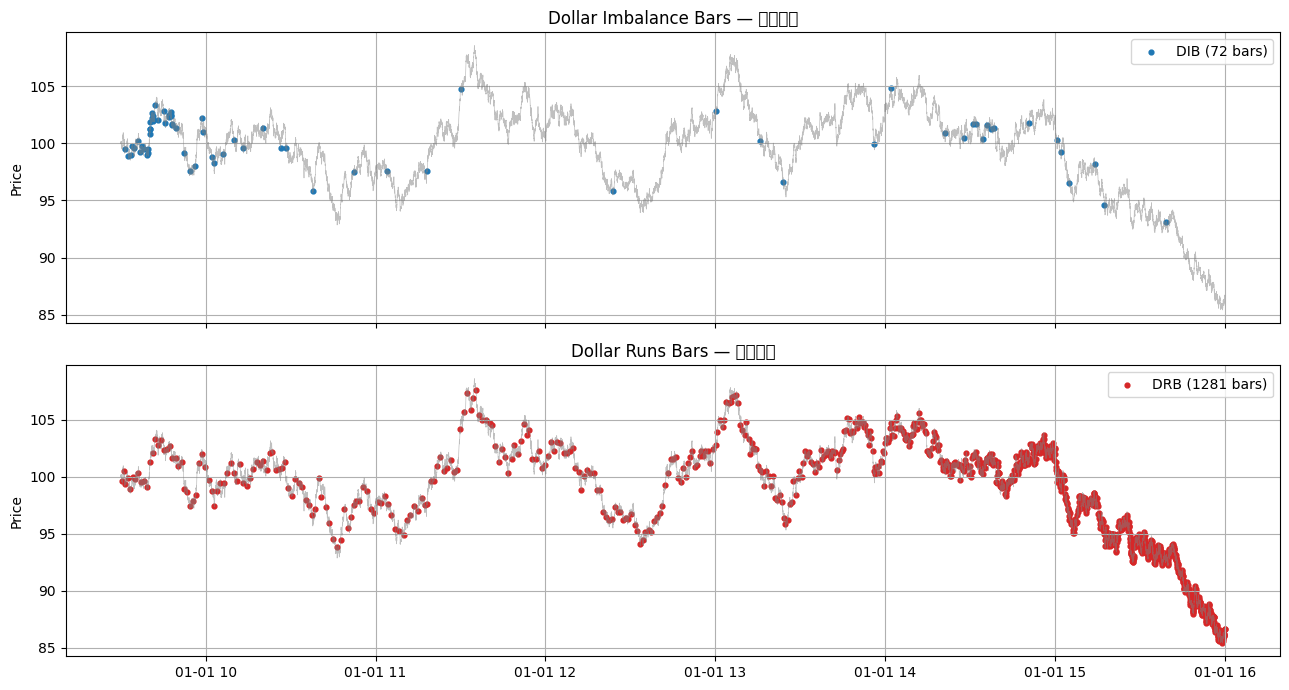

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(ticks['timestamp'], ticks['price'], lw=0.5, color='gray', alpha=0.5)
axes[0].scatter(dib['timestamp'], dib['close'], s=12, color='C0', label=f'DIB ({len(dib)} bars)')
axes[0].set_title('Dollar Imbalance Bars — 采样时点')
axes[0].set_ylabel('Price'); axes[0].legend()

axes[1].plot(ticks['timestamp'], ticks['price'], lw=0.5, color='gray', alpha=0.5)
axes[1].scatter(drb['timestamp'], drb['close'], s=12, color='C3', label=f'DRB ({len(drb)} bars)')
axes[1].set_title('Dollar Runs Bars — 采样时点')
axes[1].set_ylabel('Price'); axes[1].legend()
plt.tight_layout(); plt.show()


---

## 5. §2.4 多产品序列：ETF Trick / PCA Weights / Roll

### 5.1 ETF Trick 的动机

直接对 spread 或 basket 建模有三个问题：
1. **权重变化**会导致 spread 收敛——伪 PnL
2. **spread 可以为负**——大多数模型假设价格非负
3. **多腿不能同时成交**——执行风险 + 跨腿延迟

**解决方案**：把任意多产品 basket（含期货 roll）转成一个**等价的、永不到期的、像 ETF 的 \$1 投资价值序列 $K_t$**。

### 5.2 核心公式

给定每个 bar $t$ 的：
- $o_{i,t}, p_{i,t}$：原始开、收价
- $\varphi_{i,t}$：每点的美元价值（含汇率）
- $v_{i,t}$：成交量
- $d_{i,t}$：carry / dividend / coupon
- $\omega_t$：在 rebalance bar 集合 $B$ 上更新的权重向量

则：

$$h_{i,t} = \begin{cases} \dfrac{\omega_{i,t} K_t}{o_{i,t+1} \varphi_{i,t} \sum_i |\omega_{i,t}|} & \text{if } t \in B \\ h_{i,t-1} & \text{otherwise} \end{cases}$$

$$\delta_{i,t} = \begin{cases} p_{i,t} - o_{i,t} & \text{if } (t{-}1) \in B \\ \Delta p_{i,t} & \text{otherwise} \end{cases}$$

$$K_t = K_{t-1} + \sum_i h_{i,t-1} \varphi_{i,t} (\delta_{i,t} + d_{i,t}),\quad K_0 = 1$$

PnL 滚动 reinvest 到 $K_t$ 中 → **天然防止负值**。

另需跟踪三个辅助变量：
- **Rebalance cost** $c_t = \sum_i (|h_{i,t-1}| p_{i,t} + |h_{i,t}| o_{i,t+1}) \varphi_{i,t} \tau_i$，$t \in B$
- **Bid-ask cost** $\tilde c_t = \sum_i |h_{i,t-1}| p_{i,t} \varphi_{i,t} \tau_i$
- **Tradeable volume** $v_t = \min_i \{v_{i,t} / |h_{i,t-1}|\}$


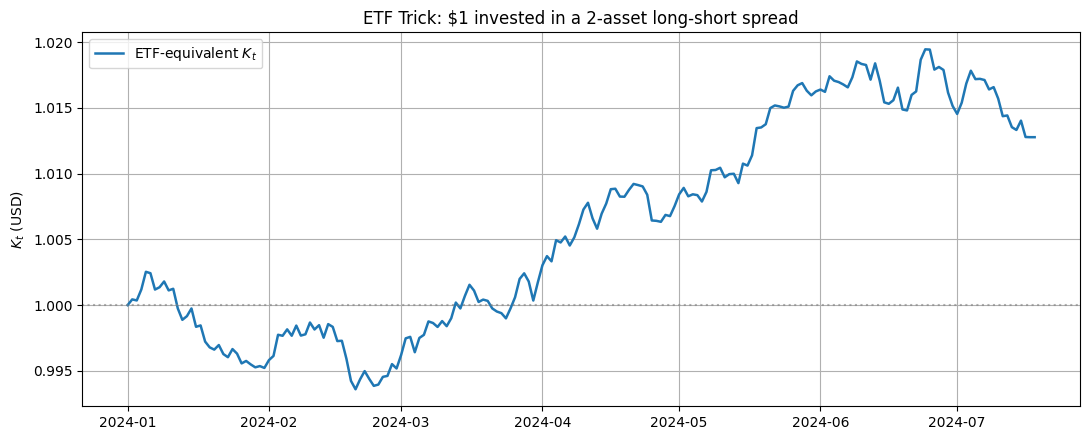

最终 K_T = 1.0128
累计 rebalance cost = 0.0036


In [11]:
def etf_trick(opens: pd.DataFrame,
              closes: pd.DataFrame,
              weights: pd.DataFrame,
              point_value: pd.DataFrame,
              dividends: Optional[pd.DataFrame] = None,
              rebalance_bars: Optional[Sequence] = None,
              transaction_cost: float = 1e-4,
              K0: float = 1.0) -> pd.DataFrame:
    """把多产品 basket 转成单个等价 ETF 的 $1 投资价值序列 K_t.

    参数（所有 DataFrame 同 index/columns）：
      opens, closes: 每个 bar 的开/收价
      weights: 期望持仓权重（rebalance bar 上更新，其他 bar 沿用）
      point_value: 每点的美元价值（含汇率）
      dividends: carry/dividend/coupon（可选）
      rebalance_bars: 要 rebalance 的 bar 索引；默认全部 bar
      transaction_cost: 每 $1 交易额的成本（如 1e-4 = 1 bp）

    返回 DataFrame 含: K, h_i, rebalance_cost, bidask_cost
    """
    T = len(opens)
    instruments = opens.columns

    if dividends is None:
        dividends = pd.DataFrame(0.0, index=opens.index, columns=opens.columns)
    if rebalance_bars is None:
        rebalance_bars = list(opens.index)
    rebalance_set = set(rebalance_bars)

    K = pd.Series(index=opens.index, dtype=float)
    K.iloc[0] = K0
    h = pd.DataFrame(0.0, index=opens.index, columns=instruments)
    delta = pd.DataFrame(0.0, index=opens.index, columns=instruments)
    rebal_cost = pd.Series(0.0, index=opens.index)
    bidask_cost = pd.Series(0.0, index=opens.index)

    # t=0 初始 holdings
    if opens.index[0] in rebalance_set:
        w0 = weights.iloc[0]
        denom = (opens.iloc[0] * point_value.iloc[0] * abs(w0).sum())
        h.iloc[0] = (w0 * K0) / denom.replace(0, np.nan)
        h.iloc[0] = h.iloc[0].fillna(0)

    for t in range(1, T):
        idx_t = opens.index[t]
        idx_prev = opens.index[t - 1]

        # delta
        if idx_prev in rebalance_set:
            delta.iloc[t] = closes.iloc[t] - opens.iloc[t]
        else:
            delta.iloc[t] = closes.iloc[t] - closes.iloc[t - 1]

        # 用 t-1 的 holdings 计算 K_t
        pnl = (h.iloc[t - 1] * point_value.iloc[t] *
               (delta.iloc[t] + dividends.iloc[t])).sum()
        K.iloc[t] = K.iloc[t - 1] + pnl

        # 更新 h_t
        if idx_t in rebalance_set:
            w_t = weights.iloc[t]
            denom = (opens.iloc[t] * point_value.iloc[t] * abs(w_t).sum())
            h.iloc[t] = (w_t * K.iloc[t]) / denom.replace(0, np.nan)
            h.iloc[t] = h.iloc[t].fillna(0)

            # rebalance cost
            rebal_cost.iloc[t] = (
                (h.iloc[t - 1].abs() * closes.iloc[t] +
                 h.iloc[t].abs() * opens.iloc[t]) *
                point_value.iloc[t] * transaction_cost
            ).sum()
        else:
            h.iloc[t] = h.iloc[t - 1]

        # bid-ask cost（任何时点买卖一份"虚拟 ETF"的成本）
        bidask_cost.iloc[t] = (
            h.iloc[t - 1].abs() * closes.iloc[t] *
            point_value.iloc[t] * transaction_cost
        ).sum()

    result = pd.DataFrame({'K': K, 'rebal_cost': rebal_cost, 'bidask_cost': bidask_cost})
    for col in instruments:
        result[f'h_{col}'] = h[col]
    return result


# 演示：两个高度相关合约的等权 basket
n = 200
idx = pd.date_range('2024-01-01', periods=n, freq='D')
rng = np.random.default_rng(7)
shock = rng.standard_normal(n) * 0.5
p1 = 100 + np.cumsum(shock + rng.standard_normal(n) * 0.1)
p2 = 100 + np.cumsum(shock + rng.standard_normal(n) * 0.1)

opens = pd.DataFrame({'A': p1, 'B': p2}, index=idx)
closes = opens.shift(-1).ffill()
weights = pd.DataFrame({'A': 0.5, 'B': -0.5}, index=idx)  # long-short spread
pv = pd.DataFrame(1.0, index=idx, columns=['A', 'B'])

# 每 20 天 rebalance 一次
rebal_dates = idx[::20]
res = etf_trick(opens, closes, weights, pv,
                rebalance_bars=rebal_dates,
                transaction_cost=2e-4)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(res.index, res['K'], label='ETF-equivalent $K_t$', lw=1.8)
ax.axhline(1.0, color='gray', ls=':', alpha=0.6)
ax.set_title('ETF Trick: $1 invested in a 2-asset long-short spread')
ax.set_ylabel('$K_t$ (USD)')
ax.legend(); plt.tight_layout(); plt.show()

print(f"最终 K_T = {res['K'].iloc[-1]:.4f}")
print(f"累计 rebalance cost = {res['rebal_cost'].sum():.4f}")


### 5.3 PCA Weights（§2.4.2）

给一个 basket 求权重 $\omega$，使**风险按用户指定的分布 $R$ 分配到各主成分**。

**推导**：
1. 谱分解 $V W = W \Lambda$，列按特征值降序排列。
2. 组合风险 $\sigma^2 = \omega' V \omega = \beta' \Lambda \beta$，其中 $\beta = W'\omega$ 是 $\omega$ 在正交基上的投影。
3. 第 $n$ 个成分贡献的风险 $R_n = \beta_n^2 \Lambda_{n,n} / \sigma^2$，满足 $\sum R_n = 1$。
4. 反解：给定目标 $R$ 和目标总风险 $\sigma$，$\beta_n = \sigma \sqrt{R_n / \Lambda_{n,n}}$。
5. 回到原基：$\omega = W \beta$。

**特殊情形**：若 $R$ 全集中到最小特征值对应的成分（即 `riskDist[-1] = 1`），就构造出一个**只对最小方差主成分敏感**的组合，是统计套利的常用构造。


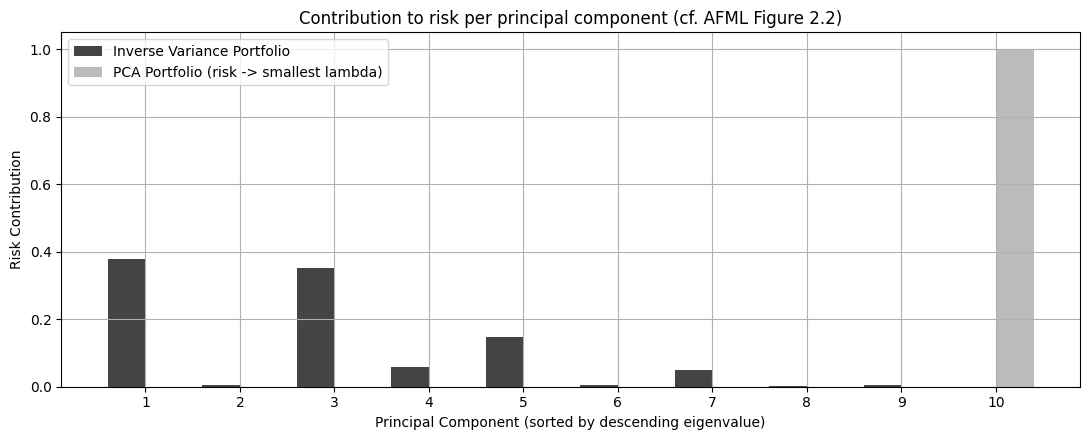

IVP 风险贡献总和： 1.0
PCA 风险贡献总和： 1.0


In [12]:
def pca_weights(cov: np.ndarray,
                risk_dist: Optional[np.ndarray] = None,
                risk_target: float = 1.0) -> np.ndarray:
    """AFML Snippet 2.1：按指定风险分布给协方差矩阵求 portfolio weights.

    参数:
      cov: NxN 协方差矩阵（Hermitian）
      risk_dist: 目标风险分布（按特征值降序对应的主成分），sum 应为 1
                 若为 None，则全部风险分配到最小特征值的主成分
      risk_target: 目标总风险（sigma）

    返回:
      omega: N 维权重向量
    """
    eVal, eVec = np.linalg.eigh(cov)  # 升序
    # 反转为降序
    order = eVal.argsort()[::-1]
    eVal, eVec = eVal[order], eVec[:, order]

    if risk_dist is None:
        risk_dist = np.zeros(cov.shape[0])
        risk_dist[-1] = 1.0  # 全部分配给最小特征值的主成分

    loads = risk_target * (risk_dist / eVal) ** 0.5
    w = eVec @ loads.reshape(-1, 1)
    return w.flatten()


def risk_contributions(weights: np.ndarray, cov: np.ndarray) -> np.ndarray:
    """算每个主成分对总组合风险的贡献比例。"""
    eVal, eVec = np.linalg.eigh(cov)
    order = eVal.argsort()[::-1]
    eVal, eVec = eVal[order], eVec[:, order]
    beta = eVec.T @ weights
    contrib = (beta ** 2) * eVal
    return contrib / contrib.sum()


# 演示：10 资产，复现 Figure 2.2
N = 10
rng = np.random.default_rng(123)
A = rng.standard_normal((N, N))
cov = A @ A.T + np.eye(N) * 0.1  # 保证正定

# 1) Inverse-variance portfolio
ivp_w = 1.0 / np.diag(cov)
ivp_w = ivp_w / ivp_w.sum()
ivp_contrib = risk_contributions(ivp_w, cov)

# 2) PCA portfolio：全部风险压在最小特征值主成分
pca_w = pca_weights(cov, risk_dist=None, risk_target=1.0)
pca_contrib = risk_contributions(pca_w, cov)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(1, N + 1)
width = 0.4
ax.bar(x - width / 2, ivp_contrib, width, label='Inverse Variance Portfolio', color='#444')
ax.bar(x + width / 2, pca_contrib, width, label='PCA Portfolio (risk -> smallest lambda)', color='#bbb')
ax.set_xlabel('Principal Component (sorted by descending eigenvalue)')
ax.set_ylabel('Risk Contribution')
ax.set_title('Contribution to risk per principal component (cf. AFML Figure 2.2)')
ax.set_xticks(x); ax.legend()
plt.tight_layout(); plt.show()

print("IVP 风险贡献总和：", ivp_contrib.sum())
print("PCA 风险贡献总和：", pca_contrib.sum())


### 5.4 Single Future Roll（§2.4.3）

期货合约到期 → 换月时前后两个合约价格有 **gap**。

**两种处理方式**：
- **Forward roll** (`match_end=False`)：以**最早合约**的价格为锚。rolled series 起点 = raw series 起点。
- **Backward roll** (`match_end=True`)：以**最近合约**的价格为锚。rolled series 终点 = raw series 终点（更常用，因为关心的是当前价格水平）。

**重要细节**：
- Rolled prices 用于 **PnL 模拟**和组合 mark-to-market；
- **Raw prices** 用于 **sizing**（持仓数量）和 **margin** 计算；
- 在 contango 期间 sold-off 的合约（如 Cotton #2、Natural Gas），rolled price **可能变成负数**——所以构造"非负的 $1 投资序列"需要进一步处理：
  1. 算 rolled price changes
  2. 除以前一个 raw price 得到 returns
  3. 用 `(1+r).cumprod()` 构造


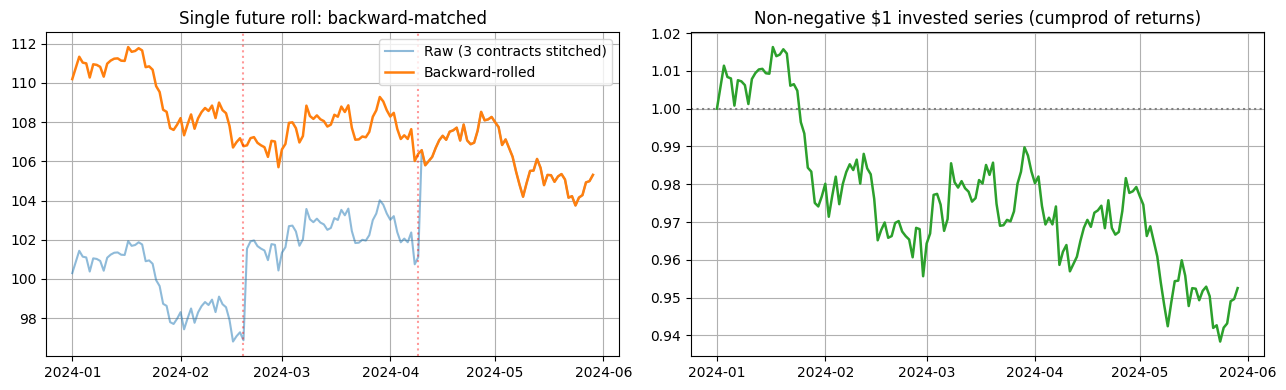

In [13]:
def roll_gaps(series: pd.DataFrame,
              instrument_col: str = 'instrument',
              open_col: str = 'open',
              close_col: str = 'close',
              match_end: bool = True) -> pd.Series:
    """AFML Snippet 2.2：计算每次 roll 的累计 gap.

    gap_t = open_t (新合约) - close_{t-1} (旧合约)，在 roll 日累计。
    """
    roll_dates = series[instrument_col].drop_duplicates(keep='first').index
    gaps = pd.Series(0.0, index=series.index)

    iloc_list = list(series.index)
    iloc_prior = [iloc_list.index(i) - 1 for i in roll_dates]

    if len(roll_dates) > 1:
        gaps.loc[roll_dates[1:]] = (
            series[open_col].loc[roll_dates[1:]].values -
            series[close_col].iloc[iloc_prior[1:]].values
        )

    gaps = gaps.cumsum()
    if match_end:
        gaps -= gaps.iloc[-1]
    return gaps


def get_rolled_series(series: pd.DataFrame,
                      instrument_col: str = 'instrument',
                      open_col: str = 'open',
                      close_col: str = 'close',
                      match_end: bool = True) -> pd.DataFrame:
    """返回去掉 roll gap 的连续价格序列。"""
    gaps = roll_gaps(series, instrument_col, open_col, close_col, match_end)
    out = series.copy()
    for col in [open_col, close_col]:
        out[col] = out[col] - gaps
    return out


def non_negative_rolled_prices(raw: pd.DataFrame,
                               instrument_col: str = 'instrument',
                               open_col: str = 'open',
                               close_col: str = 'close') -> pd.DataFrame:
    """AFML Snippet 2.3：构造非负 rolled 价格序列。

    步骤：rolled change / 前一个 raw price = return, cumprod(1+r) 得到价格。
    """
    gaps = roll_gaps(raw, instrument_col, open_col, close_col, match_end=True)
    rolled = raw.copy()
    for col in [open_col, close_col]:
        rolled[col] = rolled[col] - gaps

    rolled['returns'] = rolled[close_col].diff() / raw[close_col].shift(1)
    rolled.loc[rolled.index[0], 'returns'] = 0.0
    rolled['rPrices'] = (1 + rolled['returns']).cumprod()
    return rolled


# 演示：3 个连续期货合约，contract roll 时有 5 点 gap
n_per = 50
idx = pd.date_range('2024-01-01', periods=n_per * 3, freq='D')
rng = np.random.default_rng(11)

contracts = []
last_close = 100.0
for k, name in enumerate(['ESM4', 'ESU4', 'ESZ4']):
    walk = last_close + np.cumsum(rng.standard_normal(n_per) * 0.5)
    df_k = pd.DataFrame({
        'instrument': name,
        'open': walk,
        'close': walk + rng.standard_normal(n_per) * 0.2,
    }, index=idx[k * n_per:(k + 1) * n_per])
    contracts.append(df_k)
    last_close = df_k['close'].iloc[-1] + 5.0  # 模拟 5 点的正 roll gap

raw = pd.concat(contracts)

rolled = get_rolled_series(raw, match_end=True)
nn = non_negative_rolled_prices(raw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(raw.index, raw['close'], label='Raw (3 contracts stitched)', alpha=0.5)
axes[0].plot(rolled.index, rolled['close'], label='Backward-rolled', lw=1.8)
for c in contracts[:-1]:
    axes[0].axvline(c.index[-1], color='red', ls=':', alpha=0.4)
axes[0].set_title('Single future roll: backward-matched')
axes[0].legend()

axes[1].plot(nn.index, nn['rPrices'], color='C2', lw=1.8)
axes[1].axhline(1.0, color='gray', ls=':')
axes[1].set_title('Non-negative $1 invested series (cumprod of returns)')
plt.tight_layout(); plt.show()


---

## 6. §2.5 Sampling Features

### 6.1 为什么要 sampling？

即便已有结构化 bar 数据，直接喂 ML 还是不好：
1. 有些算法（SVM）不 scale 到大样本
2. ML 在"有信息的样本"上学得更好——预测"下一次 5% 涨跌方向"比预测"任意时点未来 5% 涨跌方向"准确率高得多

### 6.2 三种 sampling 方法

| 方法 | 做法 | 缺点 |
|------|------|------|
| **Linspace** | 固定步长抽样 | 步长任意 |
| **Uniform** | 均匀随机抽样 | 不保证有信息 |
| **Event-based** | 只在事件触发时抽样 | 需要定义事件 |

### 6.3 CUSUM Filter（§2.5.2.1）

起源是**质量控制**方法，检测某量均值偏离目标值。

**对称形式**：

$$S_t^+ = \max\{0, S_{t-1}^+ + y_t - \mathbb{E}_{t-1}[y_t]\},\quad S_0^+ = 0$$

$$S_t^- = \min\{0, S_{t-1}^- + y_t - \mathbb{E}_{t-1}[y_t]\},\quad S_0^- = 0$$

$$S_t = \max\{S_t^+,\ -S_t^-\}$$

当 $S_t \geq h$（阈值，filter size）时**触发采样**，并把对应的 $S^+$ 或 $S^-$ **重置为 0**。

**和 Bollinger Bands 的关键区别**：
- Bollinger：价格在阈值附近徘徊会**反复触发**
- CUSUM：必须**累积**长度 ≥ h 的偏离才触发一次 → 信号干净，不会刷屏

**用途**：$y_t$ 可以是价格、结构性断点统计量、熵、市场微观结构指标等。最常见用法是 $\mathbb{E}_{t-1}[y_t] = y_{t-1}$，此时 $y_t - \mathbb{E}_{t-1}[y_t]$ 就是一阶差分。


In [14]:
def cusum_filter(y: pd.Series, h) -> pd.DatetimeIndex:
    """AFML Snippet 2.4：对称 CUSUM 事件采样器.

    参数:
      y: 待过滤的时间序列（如对数价格）
      h: 阈值（filter size），可标量也可同长度 Series（动态阈值）

    返回:
      触发事件的时间索引
    """
    t_events = []
    s_pos, s_neg = 0.0, 0.0
    diff = y.diff().dropna()

    if np.isscalar(h):
        h_series = pd.Series(h, index=diff.index)
    else:
        h_series = h.reindex(diff.index).ffill()

    for ts in diff.index:
        s_pos = max(0.0, s_pos + diff.loc[ts])
        s_neg = min(0.0, s_neg + diff.loc[ts])
        h_t = h_series.loc[ts]
        if pd.isna(h_t):
            continue
        if s_neg < -h_t:
            s_neg = 0.0
            t_events.append(ts)
        elif s_pos > h_t:
            s_pos = 0.0
            t_events.append(ts)

    return pd.DatetimeIndex(t_events)


# 演示：用前面的 dollar bars 上跑 CUSUM
log_price = np.log(tb_dol.set_index('timestamp')['close'])
h = log_price.diff().std() * 2  # 阈值 = 2 * 单步收益标准差
events = cusum_filter(log_price, h)
print(f"总 bar 数: {len(log_price)}")
print(f"CUSUM 触发的事件数: {len(events)} (阈值 h = {h:.5f})")


总 bar 数: 100
CUSUM 触发的事件数: 17 (阈值 h = 0.04177)


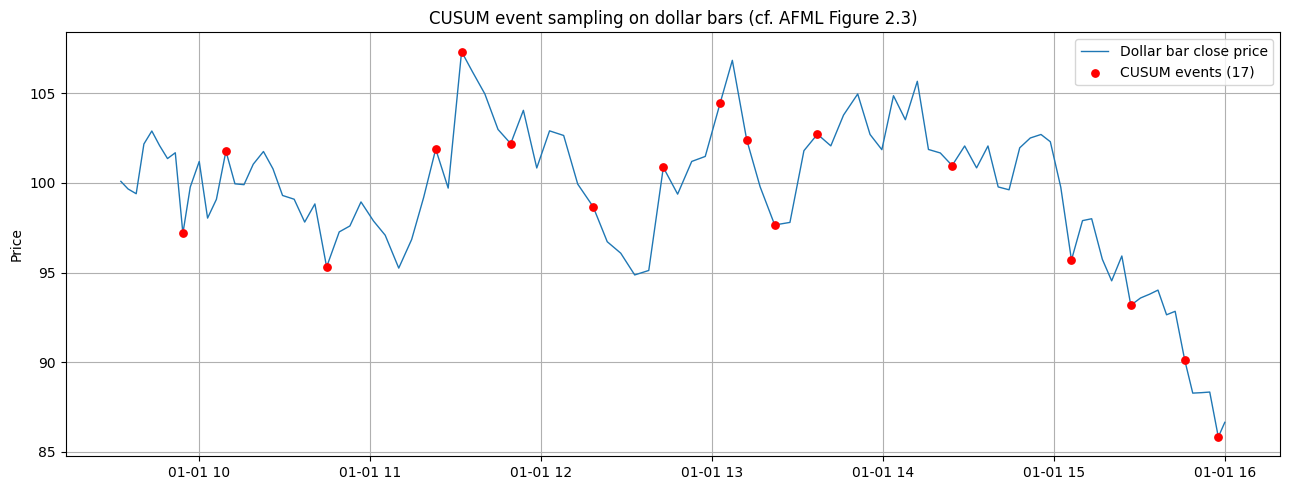

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(log_price.index, np.exp(log_price), label='Dollar bar close price', lw=1)
ax.scatter(events, np.exp(log_price.loc[events]),
           color='red', s=28, zorder=5, label=f'CUSUM events ({len(events)})')
ax.set_title('CUSUM event sampling on dollar bars (cf. AFML Figure 2.3)')
ax.set_ylabel('Price'); ax.legend()
plt.tight_layout(); plt.show()


### 6.4 CUSUM 的扩展：动态阈值

实际使用时阈值 $h$ 通常**不固定**，而是用滚动波动率自适应。


动态阈值 CUSUM 触发事件数: 10


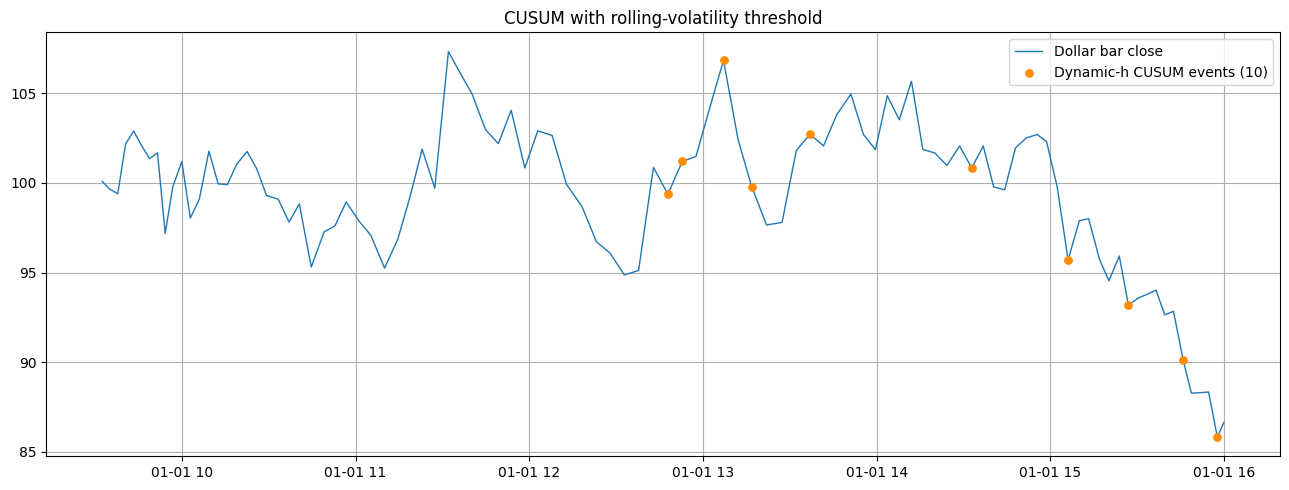

In [16]:
def dynamic_volatility_threshold(y: pd.Series,
                                  window: int = 50,
                                  multiplier: float = 2.0) -> pd.Series:
    """动态阈值：h_t = multiplier * 过去 window 期收益的滚动标准差。"""
    return y.diff().rolling(window).std() * multiplier


h_dyn = dynamic_volatility_threshold(log_price, window=50, multiplier=2.0)
events_dyn = cusum_filter(log_price, h_dyn)
print(f"动态阈值 CUSUM 触发事件数: {len(events_dyn)}")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(log_price.index, np.exp(log_price), label='Dollar bar close', lw=1)
ax.scatter(events_dyn, np.exp(log_price.loc[events_dyn]),
           color='darkorange', s=28, zorder=5,
           label=f'Dynamic-h CUSUM events ({len(events_dyn)})')
ax.set_title('CUSUM with rolling-volatility threshold')
ax.legend(); plt.tight_layout(); plt.show()


---

## 7. 习题 2.1：bar 类型对比

> "On a series of E-mini S&P 500 futures tick data:
> (a) Form tick, volume, and dollar bars. Use the ETF trick to deal with the roll.
> (b) Count the number of bars produced by tick, volume, and dollar bars on a weekly basis. Plot a time series of that bar count. What bar type produces the most stable weekly count? Why?
> (c) Compute the serial correlation of returns for the three bar types. What bar method has the lowest serial correlation?"

我们用合成数据完整跑一遍。


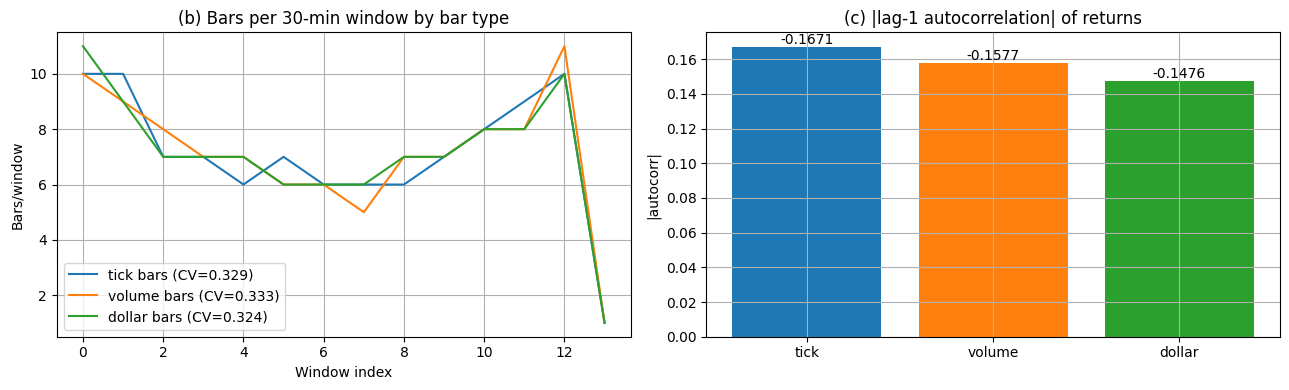


=== 结论 ===
(b) 稳定性（变异系数 CV，越小越稳）:
        tick bars: CV = 0.3288
      volume bars: CV = 0.3334
      dollar bars: CV = 0.3242
    → Dollar bars 应该最稳定，因为对价格漂移和成交量结构变化都鲁棒。

(c) 序列相关性（绝对值越小越接近 IID）:
        tick bars: lag-1 autocorr = -0.1671
      volume bars: lag-1 autocorr = -0.1577
      dollar bars: lag-1 autocorr = -0.1476
    → 文献结论：dollar bars > volume bars > tick bars > time bars。


In [17]:
def exercise_2_1(ticks: pd.DataFrame):
    """完整复现 AFML 习题 2.1。"""
    # (a) 已有 tb_tick, tb_vol, tb_dol

    # (b) 每周（这里用每日，因为合成数据只有一天）bar 数
    daily_counts = {}
    for name, b in [('tick', tb_tick), ('volume', tb_vol), ('dollar', tb_dol)]:
        daily_counts[name] = b.set_index('timestamp').resample('30min').size()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for name, s in daily_counts.items():
        cv = s.std() / s.mean() if s.mean() > 0 else np.nan
        axes[0].plot(s.values, label=f'{name} bars (CV={cv:.3f})')
    axes[0].set_title('(b) Bars per 30-min window by bar type')
    axes[0].set_xlabel('Window index'); axes[0].set_ylabel('Bars/window')
    axes[0].legend()

    # (c) 收益序列相关性
    autocorrs = {}
    for name, b in [('tick', tb_tick), ('volume', tb_vol), ('dollar', tb_dol)]:
        r = b['close'].pct_change().dropna()
        autocorrs[name] = r.autocorr(1)

    axes[1].bar(autocorrs.keys(), [abs(v) for v in autocorrs.values()],
                color=['C0', 'C1', 'C2'])
    axes[1].set_title('(c) |lag-1 autocorrelation| of returns')
    axes[1].set_ylabel('|autocorr|')
    for i, (k, v) in enumerate(autocorrs.items()):
        axes[1].text(i, abs(v), f'{v:+.4f}', ha='center', va='bottom')
    plt.tight_layout(); plt.show()

    print("\n=== 结论 ===")
    print("(b) 稳定性（变异系数 CV，越小越稳）:")
    for name, s in daily_counts.items():
        cv = s.std() / s.mean() if s.mean() > 0 else np.nan
        print(f"    {name:>8} bars: CV = {cv:.4f}")
    print("    → Dollar bars 应该最稳定，因为对价格漂移和成交量结构变化都鲁棒。")

    print("\n(c) 序列相关性（绝对值越小越接近 IID）:")
    for name, v in autocorrs.items():
        print(f"    {name:>8} bars: lag-1 autocorr = {v:+.4f}")
    print("    → 文献结论：dollar bars > volume bars > tick bars > time bars。")


exercise_2_1(ticks)


---

## 8. 全章 Takeaway

1. **数据分四类**，警惕 fundamental data 的 PIT 问题（报告日 ≠ 公开日；backfilling / reinstated values）。
2. **Time bars 是最差的采样方式**：oversample 冷清时段、undersample 热闹时段；收益有严重的 serial correlation、heteroskedasticity、非正态。GARCH 部分是为了修补这个问题。
3. **Standard bars 中 dollar bars 最好**：对价格漂移和 corporate actions 都鲁棒，每日数量最稳定。
4. **Information-driven bars** 才是 sophisticated practitioner 真正用的工具：
   - **Imbalance bars** (TIB/VIB/DIB) 监控**带符号累计量**
   - **Runs bars** (TRB/VRB/DRB) 监控**两侧分别累计的最大值**（捕捉切单行为）
   - 期望用 EWMA 估计；触发后重置
5. **ETF Trick** 把任意多腿组合（含期货 roll）转成等价的 \$1 ETF 序列，PnL 自动 reinvest → 防止负值。
6. **PCA Weights** 反向构造：从指定的"风险在主成分上的分布"求权重。
7. **Single Future Roll**：rolled prices 用于 PnL、raw prices 用于 sizing 和 margin。Contango 时 rolled price 可能变负，要用 cumprod(1+r) 构造非负序列。
8. **Event-based sampling > linspace/uniform sampling**。CUSUM filter 是默认工具：累积 h 长度的偏离才触发，比 Bollinger 干净；阈值 h 可用滚动波动率动态化。

## 9. 算法清单（本 notebook 全部实现）

| § | 算法 | 函数 |
|---|------|------|
| 2.3.1 | Time / Tick / Volume / Dollar bars | `time_bars`, `tick_bars`, `volume_bars`, `dollar_bars` |
| 2.3.2 | Tick rule | `apply_tick_rule` |
| 2.3.2 | Tick/Volume/Dollar Imbalance Bars | `imbalance_bars(mode=...)` |
| 2.3.2 | Tick/Volume/Dollar Runs Bars | `runs_bars(mode=...)` |
| 2.4.1 | ETF Trick | `etf_trick` |
| 2.4.2 | PCA portfolio weights | `pca_weights`, `risk_contributions` |
| 2.4.3 | Roll gaps / rolled series / 非负 $1 序列 | `roll_gaps`, `get_rolled_series`, `non_negative_rolled_prices` |
| 2.5.2 | CUSUM filter (static & dynamic h) | `cusum_filter`, `dynamic_volatility_threshold` |
